# EDA Shared — Sales Forecasting Datathon 2026

Six-section exploratory analysis: revenue trends, seasonality, categories,
returns, web-traffic, and customer base.
All plots saved to `outputs/`.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, re
import os as _os; _os.chdir('/Users/xps/Documents/PROJECTS/datathon/datathon-2026')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── paths (notebook executed from datathon-2026/) ─────────────────────────
DATA    = "data"
OUTPUTS = "outputs"
os.makedirs(OUTPUTS, exist_ok=True)

# ── style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.autolayout": True})

def savefig(name):
    path = os.path.join(OUTPUTS, name)
    plt.savefig(path, bbox_inches="tight")
    print(f"saved → {path}")
    plt.show()

print("Setup complete ✓")


Setup complete ✓


## Load data

In [2]:
sales       = pd.read_csv(f"{DATA}/sales.csv",       parse_dates=["Date"])
order_items = pd.read_csv(f"{DATA}/order_items.csv", low_memory=False)
products    = pd.read_csv(f"{DATA}/products.csv")
orders      = pd.read_csv(f"{DATA}/orders.csv",      parse_dates=["order_date"])
customers   = pd.read_csv(f"{DATA}/customers.csv",   parse_dates=["signup_date"])
web_traffic = pd.read_csv(f"{DATA}/web_traffic.csv", parse_dates=["date"])
returns     = pd.read_csv(f"{DATA}/returns.csv",     parse_dates=["return_date"])

sales = sales.sort_values("Date").reset_index(drop=True)
print("Loaded:")
for name, df in [("sales", sales), ("order_items", order_items),
                 ("products", products), ("orders", orders),
                 ("customers", customers), ("web_traffic", web_traffic),
                 ("returns", returns)]:
    print(f"  {name:15s}: {df.shape}")


Loaded:
  sales          : (3833, 3)
  order_items    : (714669, 7)
  products       : (2412, 8)
  orders         : (646945, 8)
  customers      : (121930, 7)
  web_traffic    : (3652, 7)
  returns        : (39939, 7)


---
## Section 1 — Revenue Trend

saved → outputs/s1a_annual_revenue.png


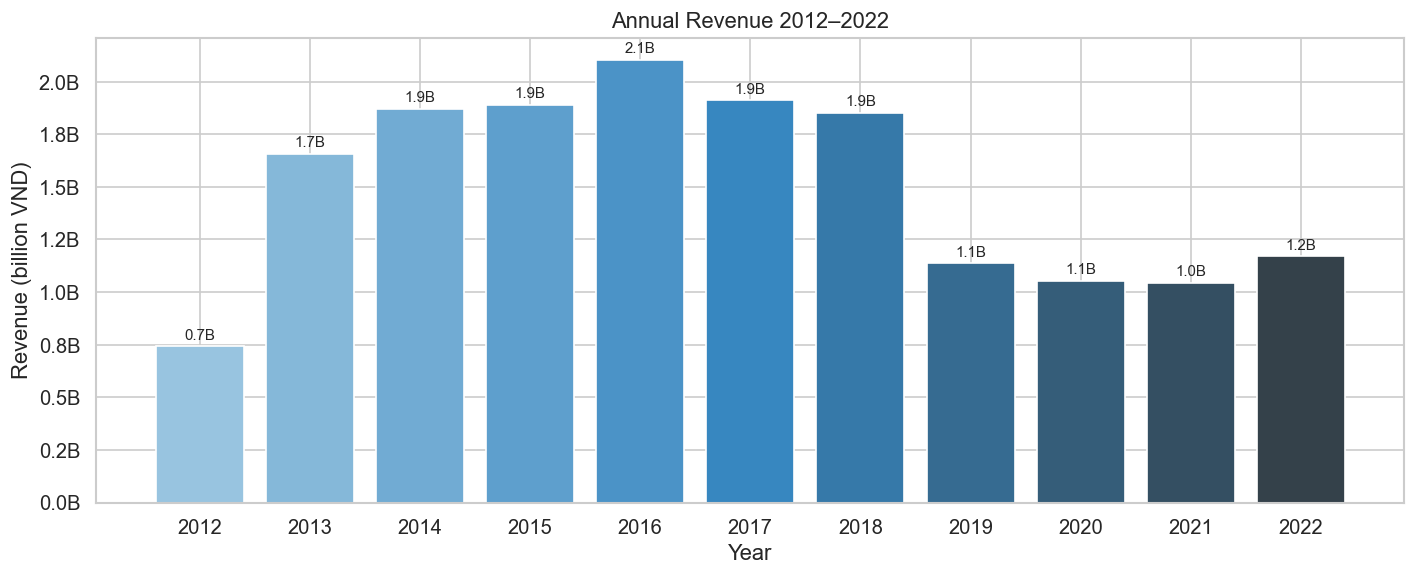

In [3]:
# ── 1a: Annual revenue bar chart 2012–2022 ─────────────────────────────────
annual = sales.set_index("Date").resample("YE")["Revenue"].sum().reset_index()
annual["Year"] = annual["Date"].dt.year

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(annual["Year"], annual["Revenue"] / 1e9, color=sns.color_palette("Blues_d", len(annual)))
ax.set_xlabel("Year")
ax.set_ylabel("Revenue (billion VND)")
ax.set_title("Annual Revenue 2012–2022")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}B"))
for bar, val in zip(bars, annual["Revenue"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val/1e9:.1f}B", ha="center", va="bottom", fontsize=9)
savefig("s1a_annual_revenue.png")


saved → outputs/s1b_monthly_heatmap.png


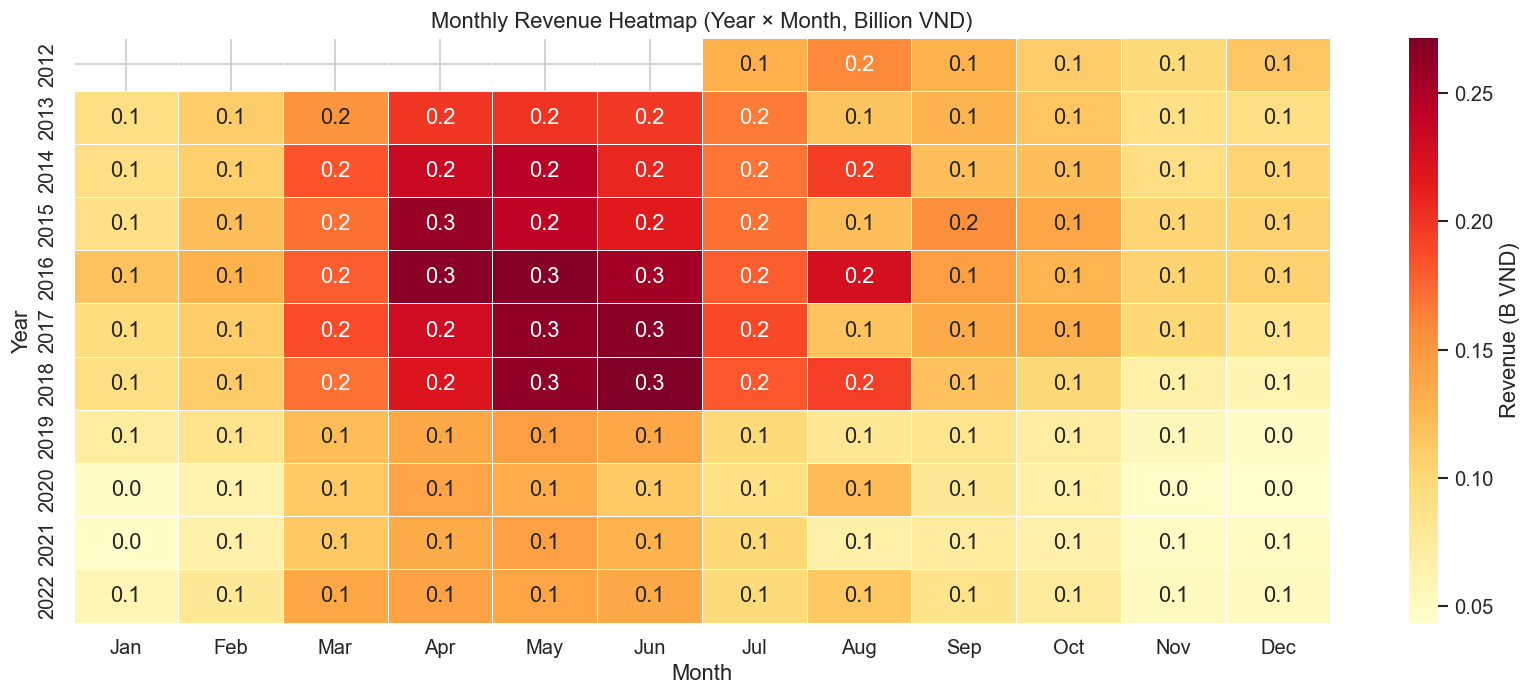

In [4]:
# ── 1b: Monthly revenue heatmap (year × month) ────────────────────────────
sales["Year"]  = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month

monthly = sales.groupby(["Year", "Month"])["Revenue"].sum().reset_index()
heatmap_data = monthly.pivot(index="Year", columns="Month", values="Revenue") / 1e9

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Revenue (B VND)"},
            xticklabels=month_labels)
ax.set_title("Monthly Revenue Heatmap (Year × Month, Billion VND)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
savefig("s1b_monthly_heatmap.png")


saved → outputs/s1c_rolling_avg.png


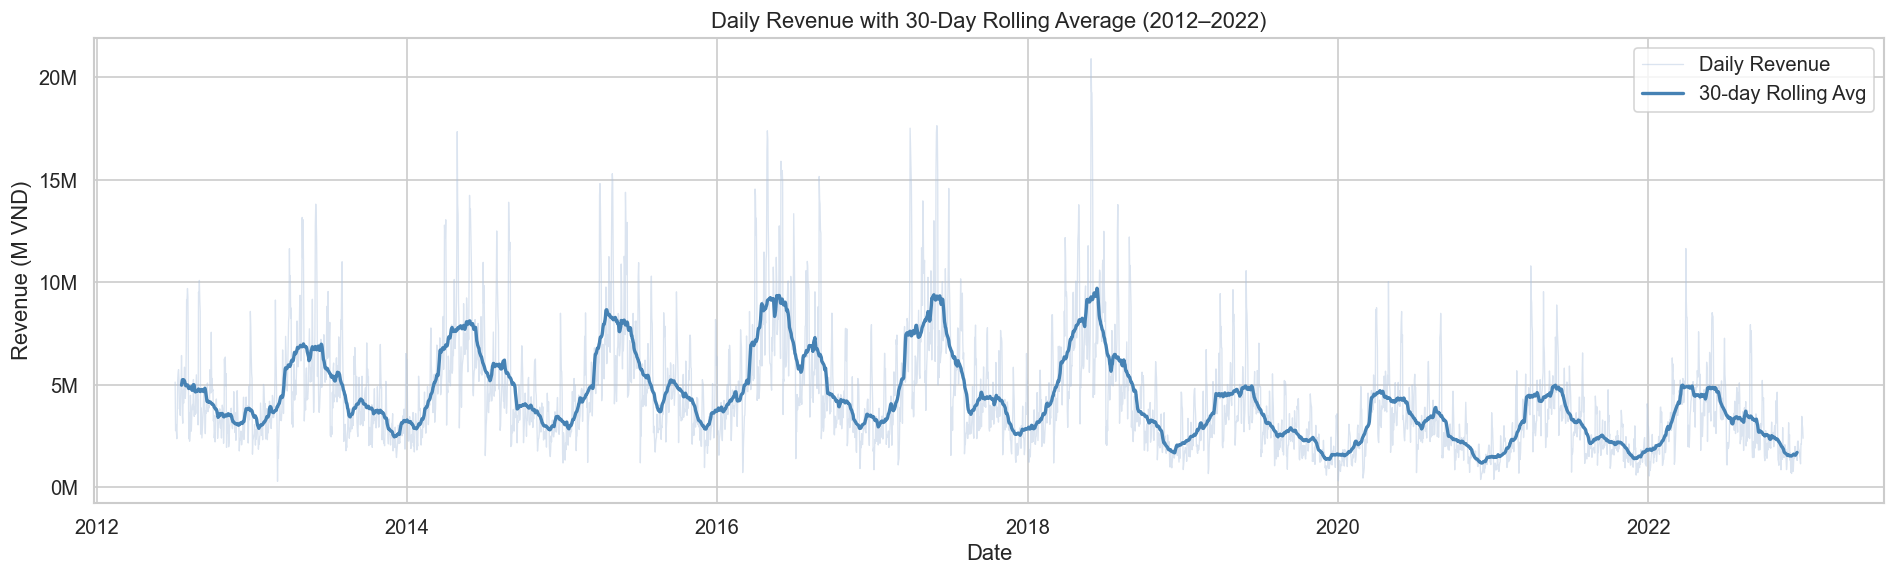

In [5]:
# ── 1c: 30-day rolling average line chart ─────────────────────────────────
daily = sales.set_index("Date")["Revenue"]
rolling = daily.rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily.index, daily / 1e6, color="lightsteelblue", alpha=0.45, linewidth=0.8, label="Daily Revenue")
ax.plot(rolling.index, rolling / 1e6, color="steelblue", linewidth=2, label="30-day Rolling Avg")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (M VND)")
ax.set_title("Daily Revenue with 30-Day Rolling Average (2012–2022)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
savefig("s1c_rolling_avg.png")


---
## Section 2 — Seasonality

saved → outputs/s2a_day_of_week.png


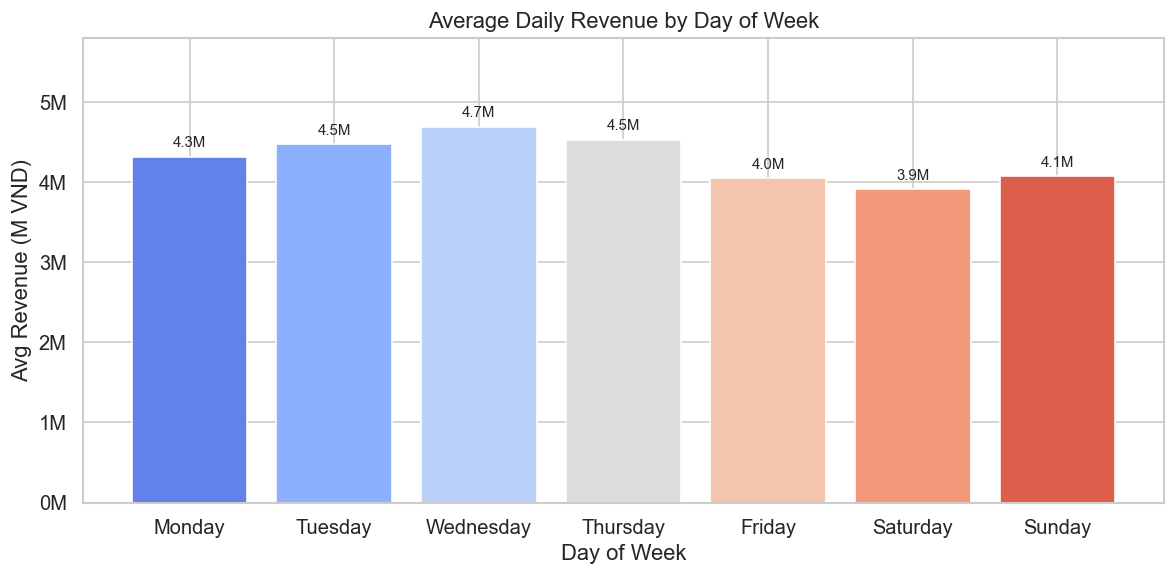

In [6]:
# ── 2a: Average revenue by day-of-week ────────────────────────────────────
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sales["DayOfWeek"] = sales["Date"].dt.day_name()
dow = sales.groupby("DayOfWeek")["Revenue"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow.index, dow / 1e6, color=sns.color_palette("coolwarm", 7))
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Revenue (M VND)")
ax.set_title("Average Daily Revenue by Day of Week")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
for bar, val in zip(bars, dow):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)
savefig("s2a_day_of_week.png")


saved → outputs/s2b_monthly_avg.png


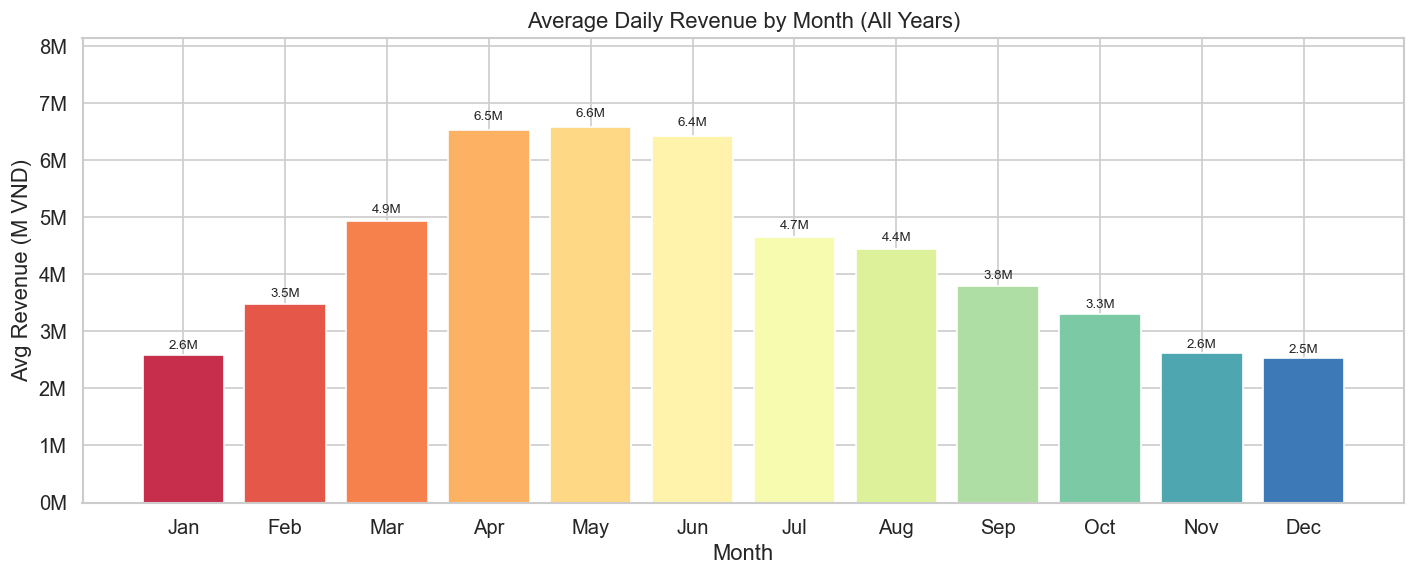

In [7]:
# ── 2b: Average revenue by month across all years ─────────────────────────
month_avg = sales.groupby("Month")["Revenue"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(month_labels, month_avg / 1e6, color=sns.color_palette("Spectral", 12))
ax.set_xlabel("Month")
ax.set_ylabel("Avg Revenue (M VND)")
ax.set_title("Average Daily Revenue by Month (All Years)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
for bar, val in zip(bars, month_avg):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=8)
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)
savefig("s2b_monthly_avg.png")


saved → outputs/s2c_vn_holidays.png


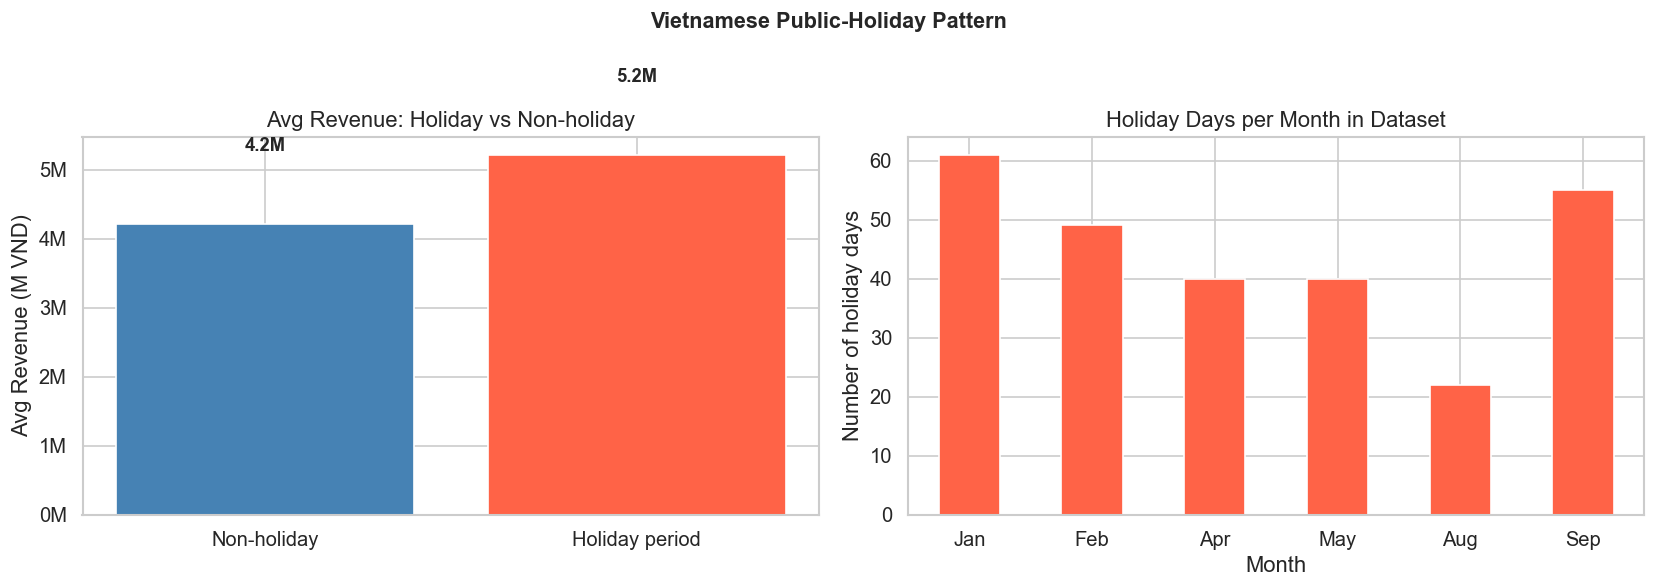

Holiday revenue lift vs non-holiday: +23.7%


In [8]:
# ── 2c: Vietnamese holidays pattern ──────────────────────────────────────
# Fixed public holidays (Gregorian)
FIXED_HOLIDAYS = {
    (1,  1): "New Year",
    (4, 30): "Reunification Day",
    (5,  1): "Labour Day",
    (9,  2): "National Day",
}
# Tết Nguyên Đán first day (Gregorian) per year
TET_DATES = {
    2012: (1, 23), 2013: (2, 10), 2014: (1, 31), 2015: (2, 19),
    2016: (2,  8), 2017: (1, 28), 2018: (2, 16), 2019: (2,  5),
    2020: (1, 25), 2021: (2, 12), 2022: (2,  1),
}
WINDOW = 3  # ± days around each holiday

def is_holiday(date):
    mm, dd, yy = date.month, date.day, date.year
    for (m, d) in FIXED_HOLIDAYS:
        if abs((date - date.replace(month=m, day=d)).days) <= WINDOW:
            return True
    if yy in TET_DATES:
        tm, td = TET_DATES[yy]
        tet = date.replace(month=tm, day=td)
        if abs((date - tet).days) <= WINDOW:
            return True
    return False

sales["is_holiday"] = sales["Date"].apply(is_holiday)

holiday_avg    = sales.groupby("is_holiday")["Revenue"].mean()
holiday_labels = {False: "Non-holiday", True: "Holiday period (±3 days)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar comparison
ax = axes[0]
vals  = [holiday_avg[False], holiday_avg[True]]
labels = ["Non-holiday", "Holiday period"]
colors = ["steelblue", "tomato"]
bars = ax.bar(labels, [v/1e6 for v in vals], color=colors)
ax.set_ylabel("Avg Revenue (M VND)")
ax.set_title("Avg Revenue: Holiday vs Non-holiday")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Right: monthly holiday-day count
ax2 = axes[1]
hol_days = sales[sales["is_holiday"]].groupby("Month").size()
hol_days.index = [["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"][m-1] for m in hol_days.index]
hol_days.plot(kind="bar", ax=ax2, color="tomato", edgecolor="white")
ax2.set_xlabel("Month")
ax2.set_ylabel("Number of holiday days")
ax2.set_title("Holiday Days per Month in Dataset")
ax2.tick_params(axis="x", rotation=0)

plt.suptitle("Vietnamese Public-Holiday Pattern", fontsize=13, fontweight="bold")
savefig("s2c_vn_holidays.png")

lift = (holiday_avg[True] - holiday_avg[False]) / holiday_avg[False] * 100
print(f"Holiday revenue lift vs non-holiday: {lift:+.1f}%")


---
## Section 3 — Category Analysis

In [9]:
# ── Join order_items + products, compute line revenue ─────────────────────
items = order_items.merge(products[["product_id","category","segment","price","cogs"]],
                          on="product_id", how="left")
items["line_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"]
print(f"Joined items: {items.shape}  |  nulls in category: {items['category'].isna().sum()}")


Joined items: (714669, 12)  |  nulls in category: 0


saved → outputs/s3a_top_categories.png


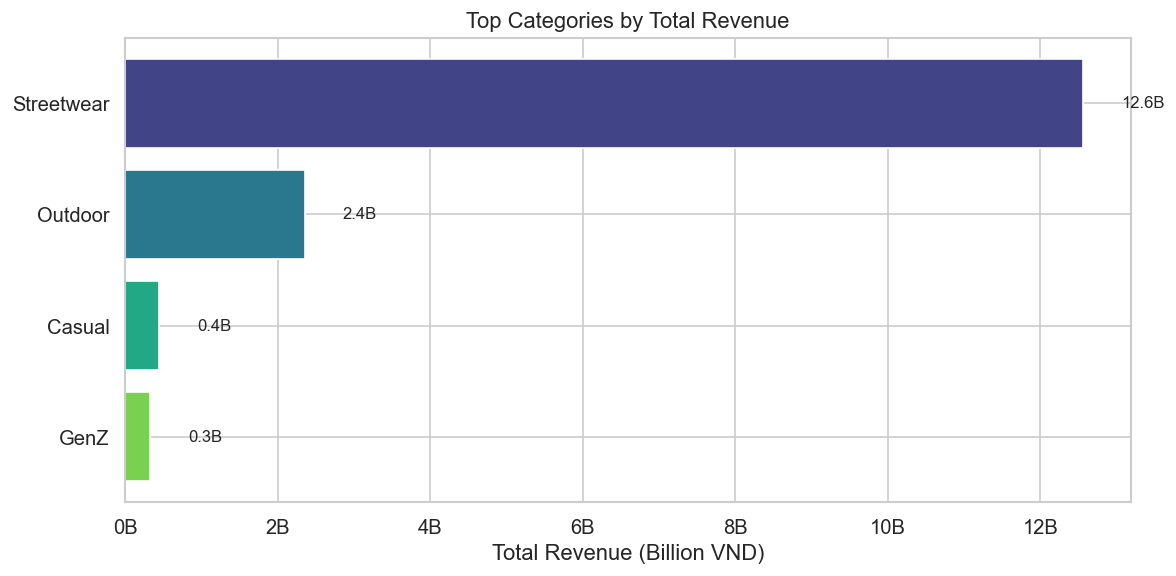

In [10]:
# ── 3a: Top categories by total revenue ──────────────────────────────────
# (Only 4 categories exist; chart shows all, labelled 'top N' for completeness)
cat_rev = (items.groupby("category")["line_revenue"]
               .sum()
               .sort_values(ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("viridis", len(cat_rev))
bars = ax.barh(cat_rev.index[::-1], cat_rev.values[::-1] / 1e9, color=palette[::-1])
ax.set_xlabel("Total Revenue (Billion VND)")
ax.set_title("Top Categories by Total Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}B"))
for bar, val in zip(bars, cat_rev.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e9:.1f}B", va="center", fontsize=10)
savefig("s3a_top_categories.png")


saved → outputs/s3b_segment_revenue.png


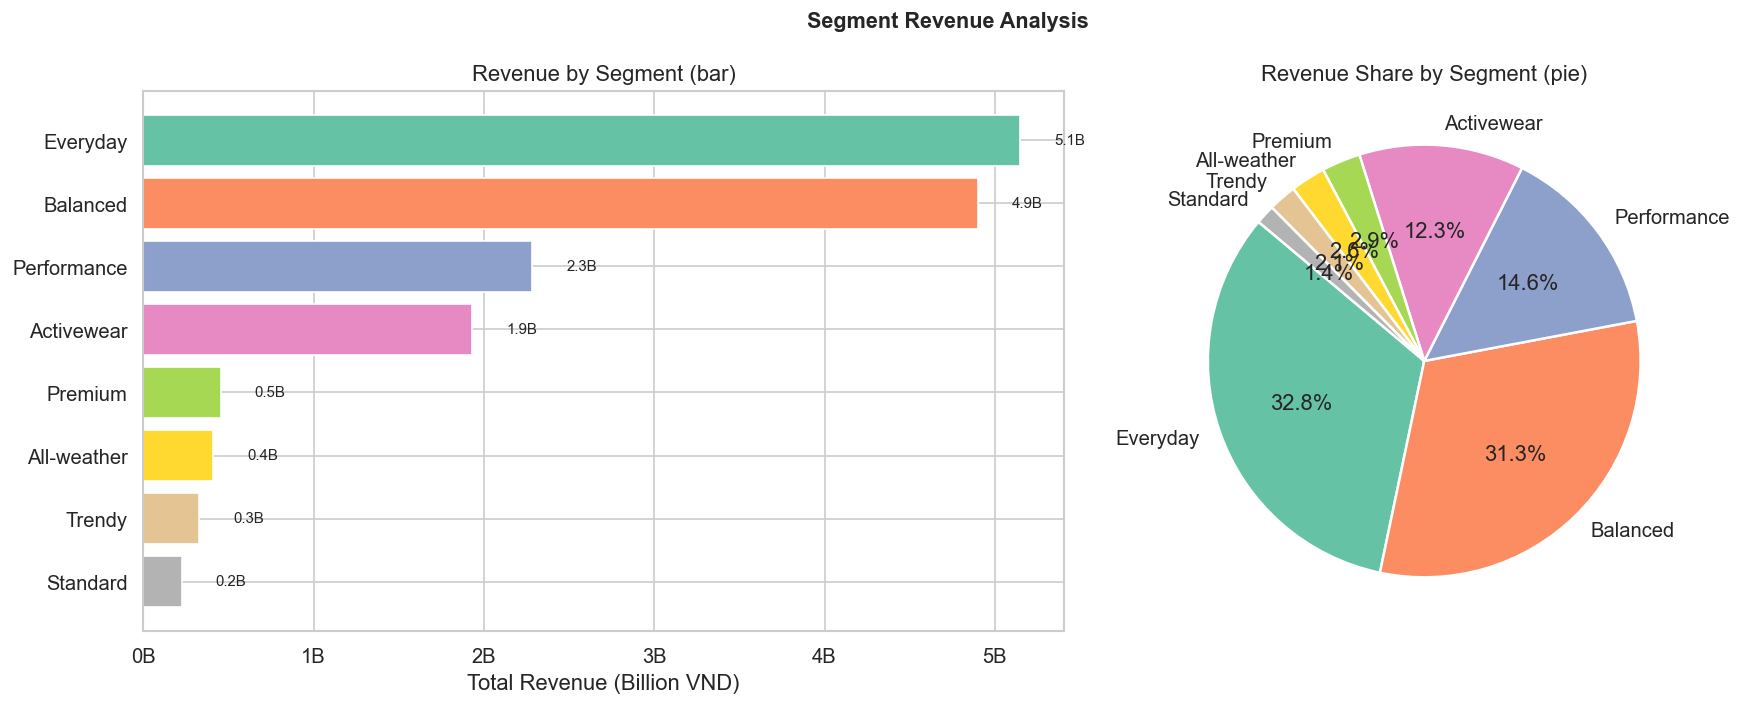

In [11]:
# ── 3b: Revenue share by segment ─────────────────────────────────────────
seg_rev = (items.groupby("segment")["line_revenue"]
               .sum()
               .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar
ax1 = axes[0]
palette2 = sns.color_palette("Set2", len(seg_rev))
bars = ax1.barh(seg_rev.index[::-1], seg_rev.values[::-1] / 1e9, color=palette2[::-1])
ax1.set_xlabel("Total Revenue (Billion VND)")
ax1.set_title("Revenue by Segment (bar)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}B"))
for bar, val in zip(bars, seg_rev.values[::-1]):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val/1e9:.1f}B", va="center", fontsize=9)

# Pie
ax2 = axes[1]
wedge_props = {"edgecolor": "white", "linewidth": 1.5}
ax2.pie(seg_rev.values, labels=seg_rev.index, autopct="%1.1f%%",
        colors=palette2, wedgeprops=wedge_props, startangle=140)
ax2.set_title("Revenue Share by Segment (pie)")

plt.suptitle("Segment Revenue Analysis", fontsize=13, fontweight="bold")
savefig("s3b_segment_revenue.png")


---
## Section 4 — Returns

            units_ordered  units_returned  return_rate
category                                              
GenZ               166848            5869         3.52
Outdoor           1170000           40417         3.45
Streetwear        1768826           59801         3.38
Casual             107469            3499         3.26
saved → outputs/s4a_return_rate_by_category.png


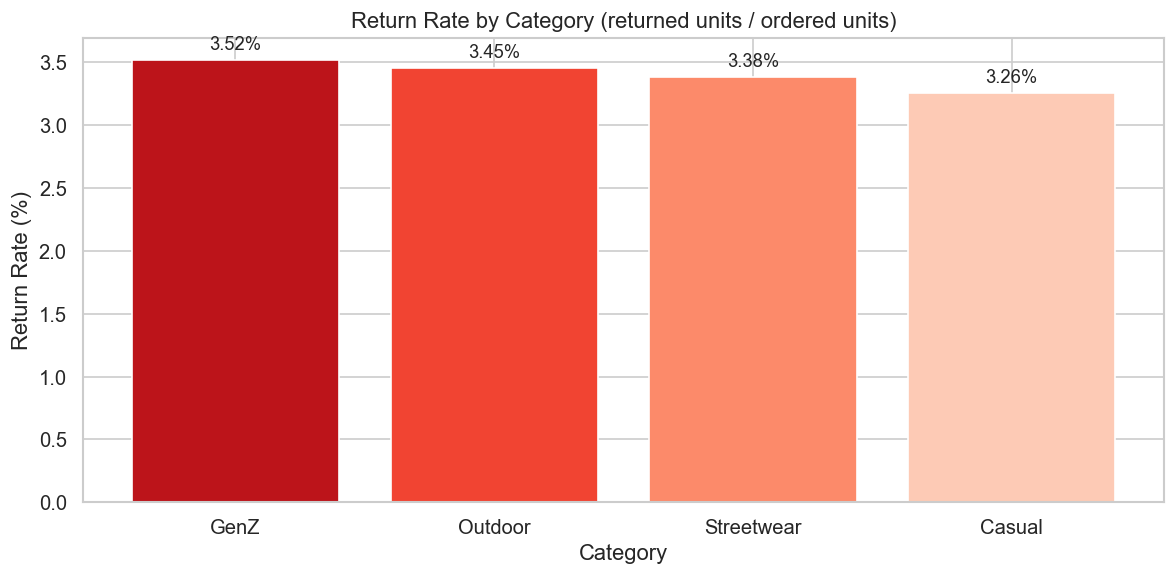

In [12]:
# ── 4a: Return rate by category ───────────────────────────────────────────
# Denominator: total units ordered per category
ordered_by_cat = (items.groupby("category")["quantity"].sum()
                       .rename("units_ordered"))

# Numerator: total returned units per category (join returns → products for category)
ret_with_cat = returns.merge(products[["product_id","category"]], on="product_id", how="left")
returned_by_cat = (ret_with_cat.groupby("category")["return_quantity"].sum()
                               .rename("units_returned"))

rate_df = pd.concat([ordered_by_cat, returned_by_cat], axis=1).fillna(0)
rate_df["return_rate"] = rate_df["units_returned"] / rate_df["units_ordered"] * 100
rate_df = rate_df.sort_values("return_rate", ascending=False)
print(rate_df.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Reds_r", len(rate_df))
bars = ax.bar(rate_df.index, rate_df["return_rate"], color=colors)
ax.set_xlabel("Category")
ax.set_ylabel("Return Rate (%)")
ax.set_title("Return Rate by Category (returned units / ordered units)")
for bar, val in zip(bars, rate_df["return_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=11)
savefig("s4a_return_rate_by_category.png")


All return reasons:
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
saved → outputs/s4b_top_return_reasons.png


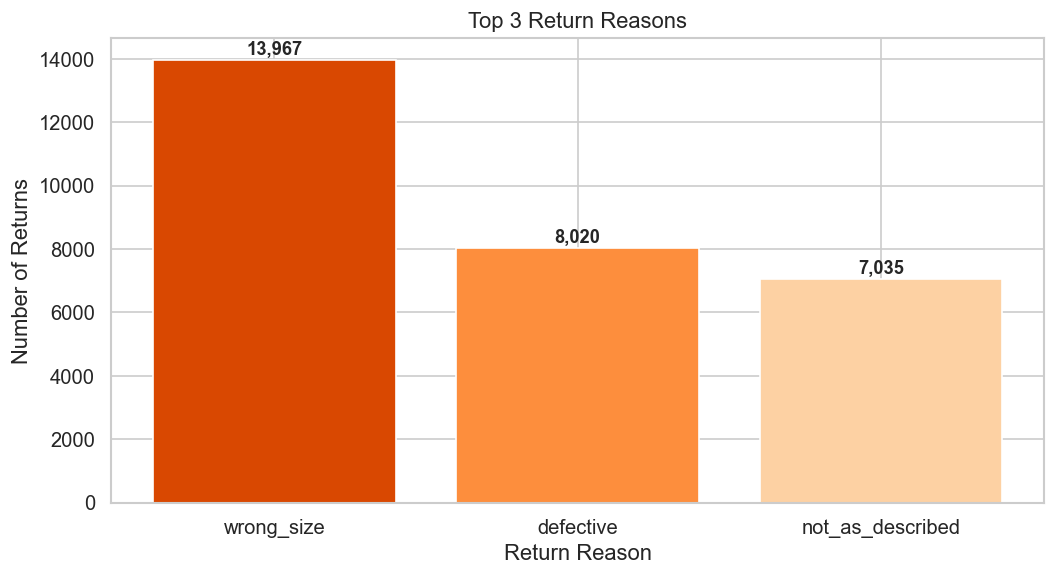

In [13]:
# ── 4b: Top 3 return reasons ─────────────────────────────────────────────
reason_counts = returns["return_reason"].value_counts()
print("All return reasons:")
print(reason_counts.to_string())

top3 = reason_counts.head(3)
fig, ax = plt.subplots(figsize=(9, 5))
palette3 = sns.color_palette("Oranges_r", 3)
bars = ax.bar(top3.index, top3.values, color=palette3)
ax.set_xlabel("Return Reason")
ax.set_ylabel("Number of Returns")
ax.set_title("Top 3 Return Reasons")
for bar, val in zip(bars, top3.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
savefig("s4b_top_return_reasons.png")


---
## Section 5 — Web Traffic vs Revenue

In [14]:
# ── Aggregate web_traffic by date (multiple rows per date / source) ────────
numeric_cols = ["sessions","unique_visitors","page_views","bounce_rate","avg_session_duration_sec"]
wt_daily = (web_traffic.groupby("date")[numeric_cols]
                        .sum()           # sum sessions/visitors/views; bounce_rate summed then handled below
                        .reset_index())
# bounce_rate: use mean across sources instead of sum
wt_bounce = web_traffic.groupby("date")["bounce_rate"].mean().reset_index()
wt_daily["bounce_rate"] = wt_bounce["bounce_rate"].values

# Merge with sales (inner: 2013-2022 overlap)
traffic_sales = wt_daily.merge(sales[["Date","Revenue"]], left_on="date", right_on="Date", how="inner")
traffic_sales = traffic_sales.drop(columns=["Date"])
print(f"Merged shape: {traffic_sales.shape}  date range: {traffic_sales['date'].min().date()} → {traffic_sales['date'].max().date()}")
print(f"Note: 2012-H2 dropped (web_traffic starts 2013-01-01)")


Merged shape: (3652, 7)  date range: 2013-01-01 → 2022-12-31
Note: 2012-H2 dropped (web_traffic starts 2013-01-01)


saved → outputs/s5a_sessions_vs_revenue.png


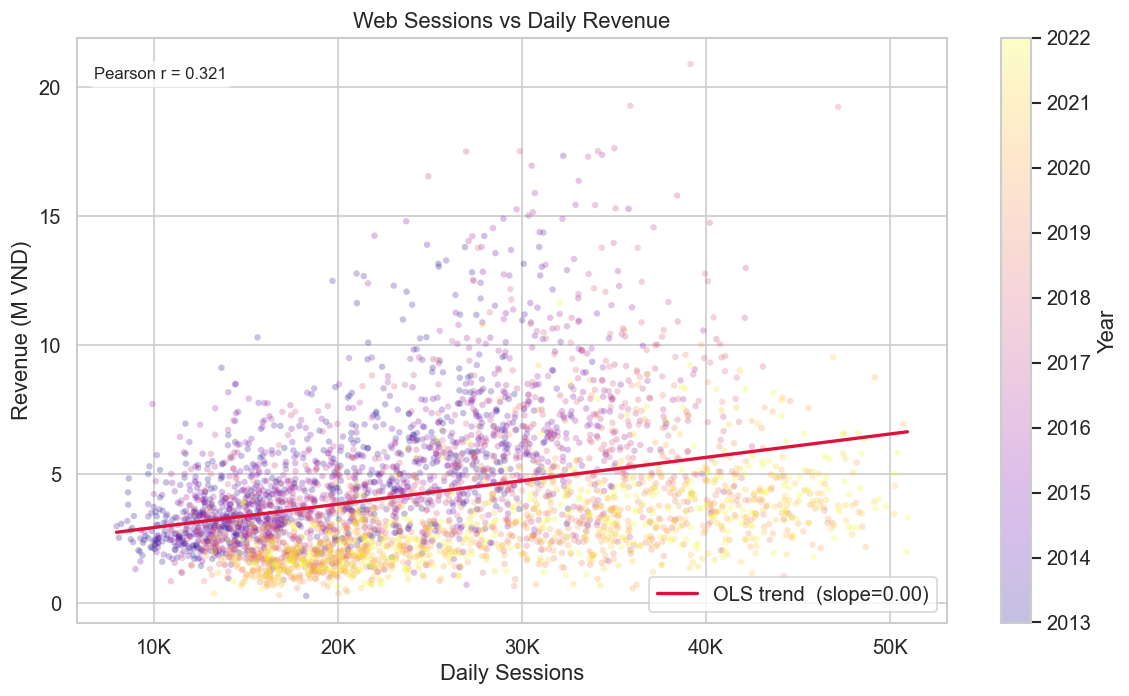

In [15]:
# ── 5a: Scatter — sessions vs Revenue ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(traffic_sales["sessions"], traffic_sales["Revenue"] / 1e6,
                alpha=0.25, s=15, c=traffic_sales["date"].dt.year,
                cmap="plasma", edgecolors="none")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Year")
# Trend line
m, b = np.polyfit(traffic_sales["sessions"], traffic_sales["Revenue"] / 1e6, 1)
xs = np.linspace(traffic_sales["sessions"].min(), traffic_sales["sessions"].max(), 200)
ax.plot(xs, m * xs + b, color="crimson", linewidth=2, label=f"OLS trend  (slope={m:.2f})")
ax.set_xlabel("Daily Sessions")
ax.set_ylabel("Revenue (M VND)")
ax.set_title("Web Sessions vs Daily Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend()
r = traffic_sales["sessions"].corr(traffic_sales["Revenue"])
ax.text(0.02, 0.95, f"Pearson r = {r:.3f}", transform=ax.transAxes,
        fontsize=10, va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
savefig("s5a_sessions_vs_revenue.png")


saved → outputs/s5b_correlation_table.png


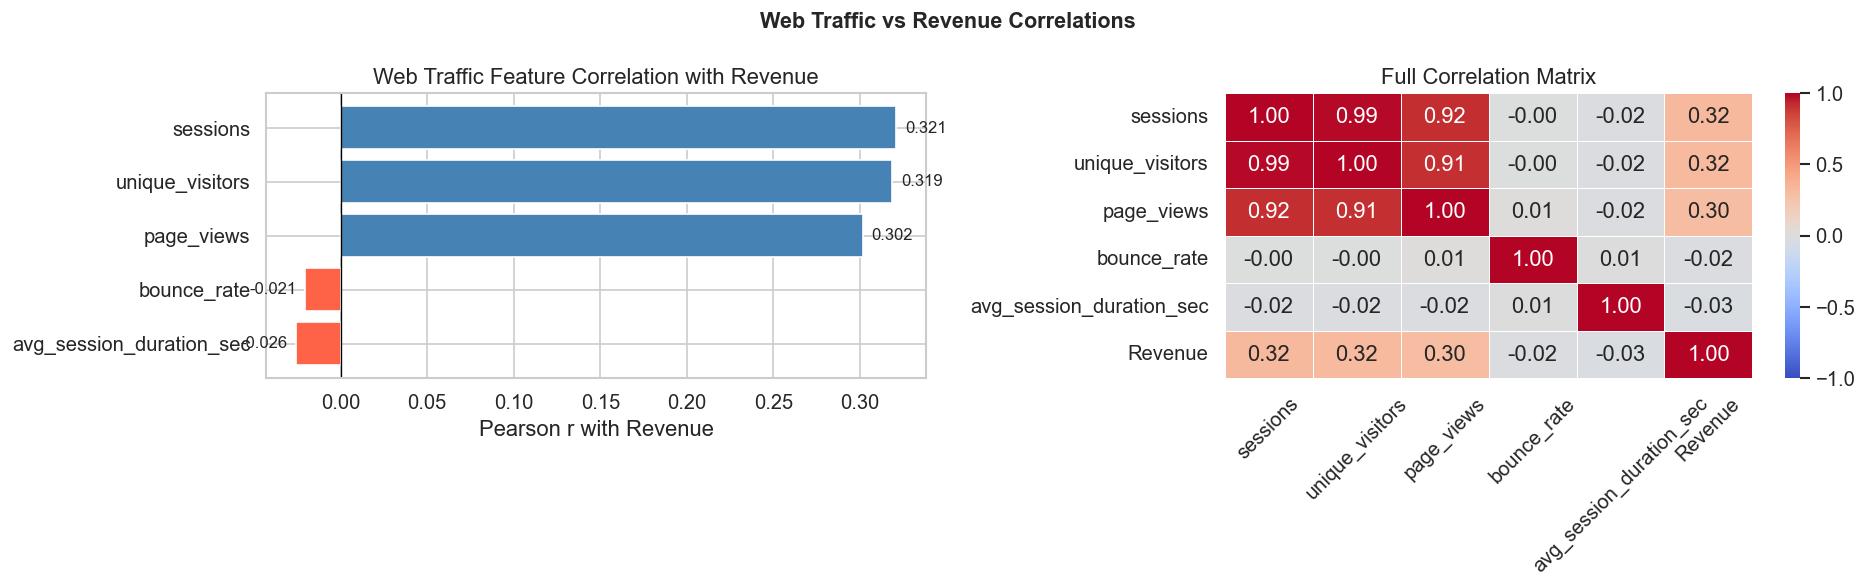


Correlation with Revenue:
sessions                    0.3211
unique_visitors             0.3188
page_views                  0.3016
bounce_rate                -0.0206
avg_session_duration_sec   -0.0256


In [16]:
# ── 5b: Correlation table — web_traffic numeric cols vs Revenue ────────────
corr_cols = numeric_cols + ["Revenue"]
corr_matrix = traffic_sales[corr_cols].corr()
rev_corr = corr_matrix["Revenue"].drop("Revenue").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar: correlation with Revenue
ax1 = axes[0]
colors_corr = ["tomato" if v < 0 else "steelblue" for v in rev_corr.values]
bars = ax1.barh(rev_corr.index[::-1], rev_corr.values[::-1], color=colors_corr[::-1])
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Pearson r with Revenue")
ax1.set_title("Web Traffic Feature Correlation with Revenue")
for bar, val in zip(bars, rev_corr.values[::-1]):
    offset = 0.005 if val >= 0 else -0.005
    ha = "left" if val >= 0 else "right"
    ax1.text(val + offset, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", ha=ha, fontsize=10)

# Heatmap: full correlation matrix
ax2 = axes[1]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=ax2, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.index)
ax2.set_title("Full Correlation Matrix")
ax2.tick_params(axis="x", rotation=45)

plt.suptitle("Web Traffic vs Revenue Correlations", fontsize=13, fontweight="bold")
savefig("s5b_correlation_table.png")

print("\nCorrelation with Revenue:")
print(rev_corr.round(4).to_string())


---
## Section 6 — Customer Base

saved → outputs/s6a_new_customers_per_year.png


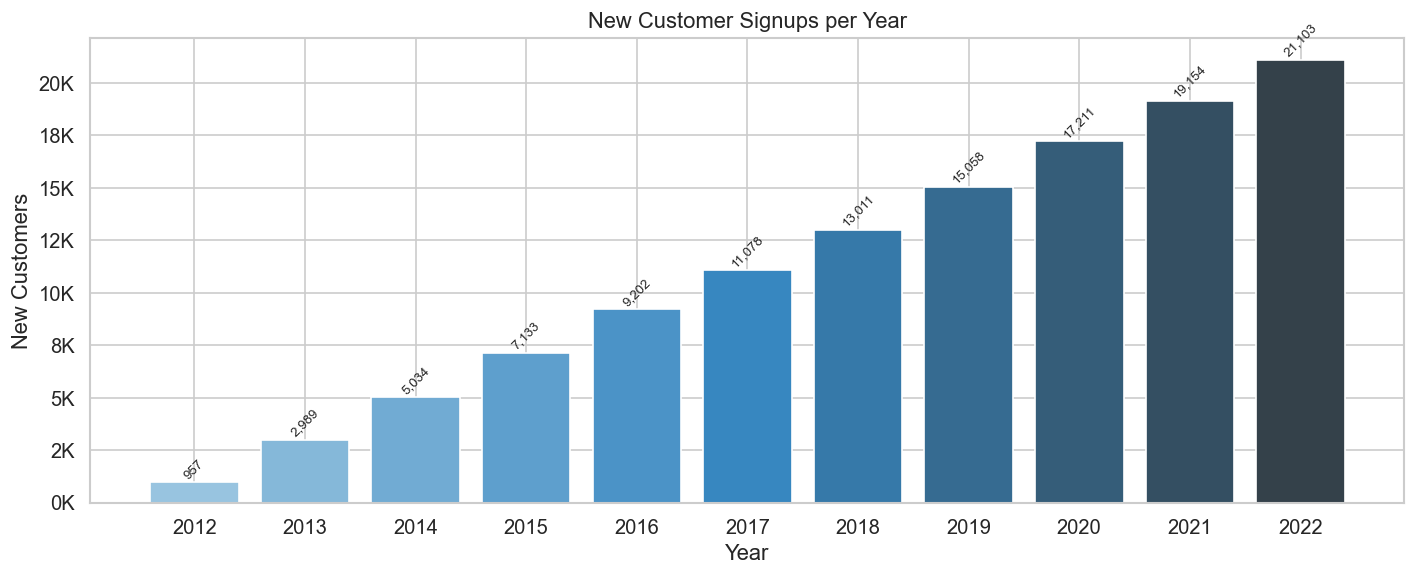

In [17]:
# ── 6a: New customers per year ────────────────────────────────────────────
customers["signup_year"] = customers["signup_date"].dt.year
new_per_year = customers.groupby("signup_year").size()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(new_per_year.index, new_per_year.values,
              color=sns.color_palette("Blues_d", len(new_per_year)))
ax.set_xlabel("Year")
ax.set_ylabel("New Customers")
ax.set_title("New Customer Signups per Year")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, val in zip(bars, new_per_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=8, rotation=45)
savefig("s6a_new_customers_per_year.png")


saved → outputs/s6b_acquisition_channels.png


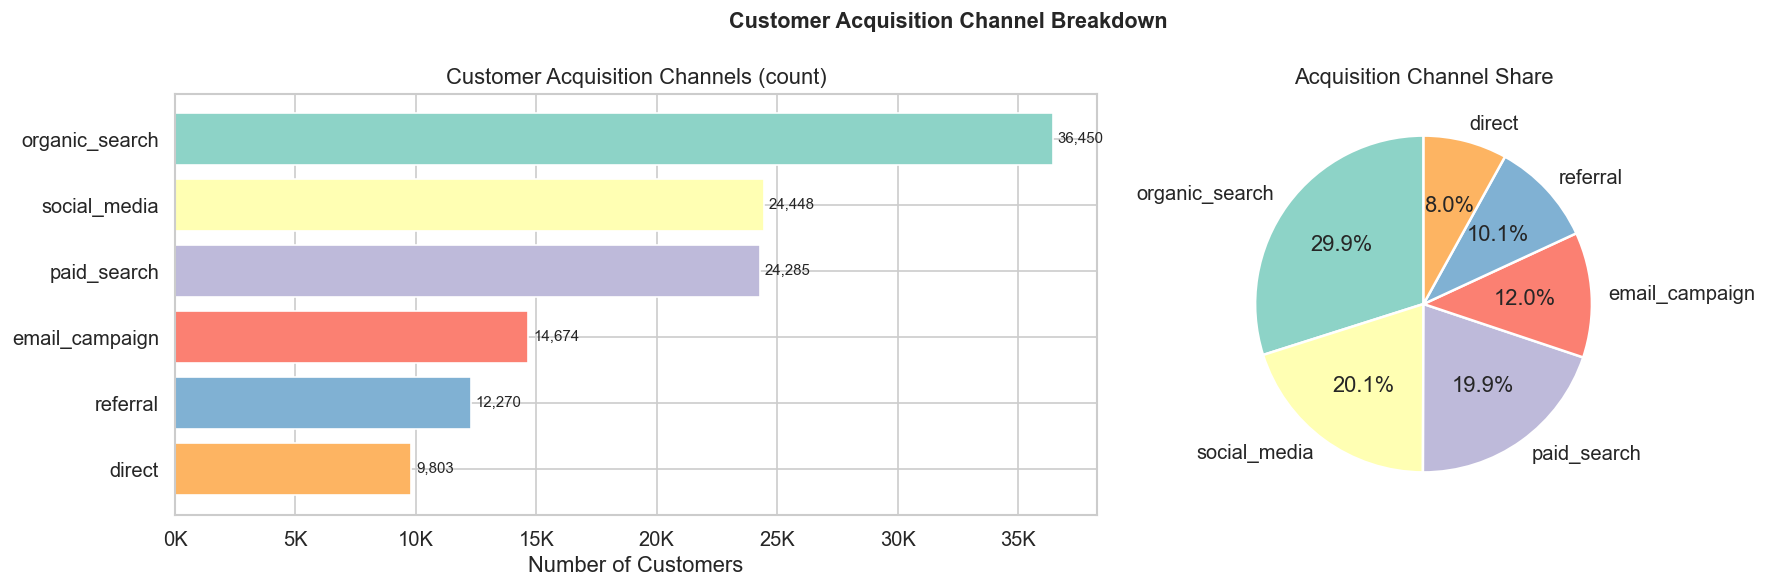

In [18]:
# ── 6b: Acquisition channel breakdown ────────────────────────────────────
channel = customers["acquisition_channel"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette4 = sns.color_palette("Set3", len(channel))

# Bar
ax1 = axes[0]
bars = ax1.barh(channel.index[::-1], channel.values[::-1], color=palette4[::-1])
ax1.set_xlabel("Number of Customers")
ax1.set_title("Customer Acquisition Channels (count)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, val in zip(bars, channel.values[::-1]):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

# Pie
ax2 = axes[1]
ax2.pie(channel.values, labels=channel.index, autopct="%1.1f%%",
        colors=palette4, wedgeprops={"edgecolor": "white", "linewidth": 1.5}, startangle=90)
ax2.set_title("Acquisition Channel Share")

plt.suptitle("Customer Acquisition Channel Breakdown", fontsize=13, fontweight="bold")
savefig("s6b_acquisition_channels.png")


saved → outputs/s6c_age_group_distribution.png


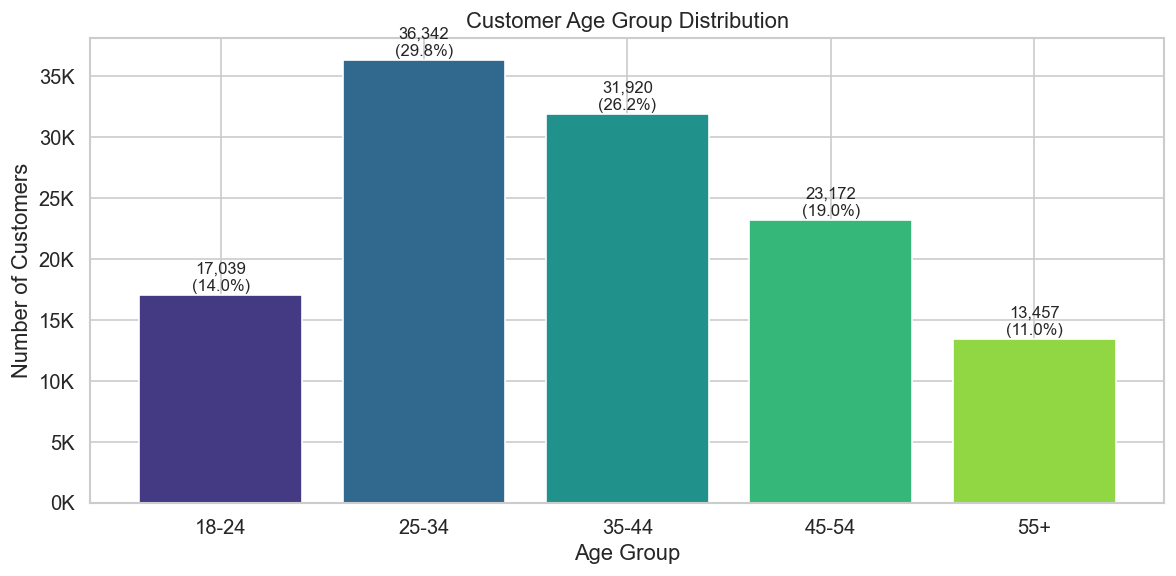

In [19]:
# ── 6c: Age group distribution ────────────────────────────────────────────
age_order  = ["18-24", "25-34", "35-44", "45-54", "55+"]
age_counts = customers["age_group"].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
palette5 = sns.color_palette("viridis", len(age_order))
bars = ax.bar(age_counts.index, age_counts.values, color=palette5)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Age Group Distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
total = age_counts.sum()
for bar, val in zip(bars, age_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}\n({val/total*100:.1f}%)", ha="center", va="bottom", fontsize=10)
savefig("s6c_age_group_distribution.png")
